In [7]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [8]:
#Load Dataset

file_path = "/content/Dataset for Data Analytics (3).xlsx"

df = pd.read_excel(file_path)

# Display first 5 rows
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [10]:
#Task 1
print("Data Collection & Dataset Understanding")
print("Dataset Shape:",df.shape)
print("Column Names:",df.columns)
print("Data Type:",df.dtypes)
print("Dataset Information:",df.info())
print("Statistical Summary:",df.describe())






Data Collection & Dataset Understanding
Dataset Shape: (1200, 14)
Column Names: Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')
Data Type: OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------     

In [11]:
#Task 2
print("Data Cleaning & Preprocessing")
print("Missing Values:")
print(df.isnull().sum())

#Remove Duplicates
before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print("Duplicates Removed:", before - after)

#Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

print("Cleaned Dataset Info:")
print(df.info())

Data Cleaning & Preprocessing
Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64
Duplicates Removed: 0
Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object

In [12]:
#Task 3
print("Exploratory Data Analysis (EDA)")

#Top selling products
print("Top Selling Products:")
print(df['Product'].value_counts())

#Order status Analysis
print("Order Status Distribution:")
print(df['OrderStatus'].value_counts())

#Payment method analysis
print("Payment Method Usage:")
print(df['PaymentMethod'].value_counts())

#Total revenue
total_revenue = df['TotalPrice'].sum()
print("Total Revenue:", total_revenue)

#Average order value
average_order = df['TotalPrice'].mean()
print("Average Order Value:", average_order)

#Monthly saled trend
monthly_sales = df.groupby(
    df['Date'].dt.month
)['TotalPrice'].sum()

print("Monthly Sales:")
print(monthly_sales)




Exploratory Data Analysis (EDA)
Top Selling Products:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
Order Status Distribution:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
Payment Method Usage:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64
Total Revenue: 1264761.96
Average Order Value: 1053.9683
Monthly Sales:
Date
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64


Data Visualization


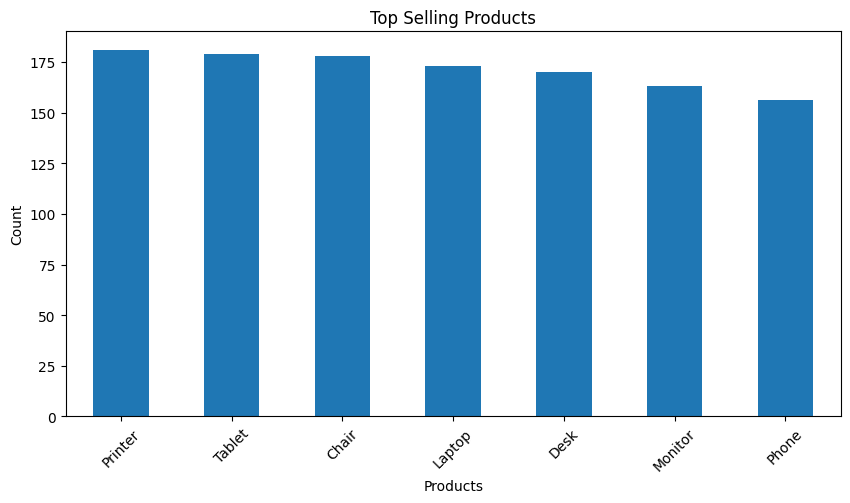

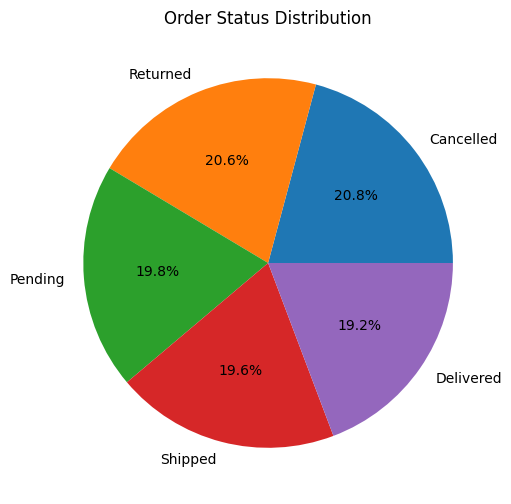

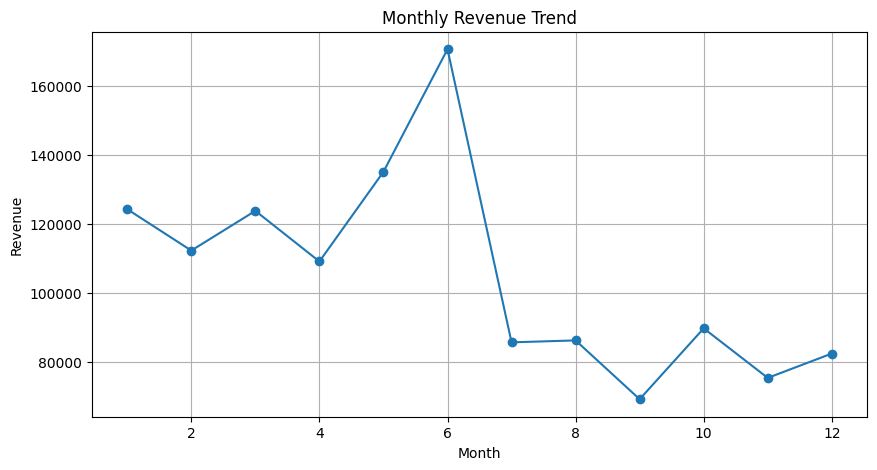

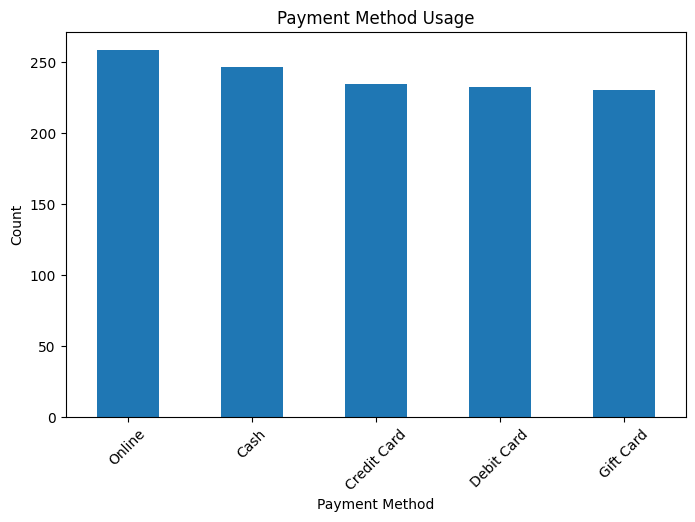

In [13]:
#Task 4
print("Data Visualization")

#Top selling products bar chart
product_sales = df['Product'].value_counts()

plt.figure(figsize=(10,5))

product_sales.plot(kind='bar')

plt.title("Top Selling Products")

plt.xlabel("Products")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

#Order status pie chart
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(6,6))

status_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Order Status Distribution")

plt.ylabel("")

plt.show()

#Monthly revenue trend
monthly_sales = df.groupby(
    df['Date'].dt.month
)['TotalPrice'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

#payment method bar chart
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8,5))

payment_counts.plot(kind='bar')

plt.title("Payment Method Usage")

plt.xlabel("Payment Method")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [14]:
#Task 5
print("Predictive Model / Machine Learning")

#Split Train Test
X = df[['Quantity', 'UnitPrice', 'ItemsInCart']]

y = df['TotalPrice']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#linear regression model
model = LinearRegression()

model.fit(X_train, y_train)

#Make prediction
y_pred = model.predict(X_test)

#Model Evaluations
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")

print("------------------------")

print("MAE:", mae)

print("MSE:", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

#Sample Predictions
sample_data = [[3, 500, 5]]

prediction = model.predict(sample_data)

print("Predicted Total Price:", prediction[0])

Predictive Model / Machine Learning
Model Evaluation Metrics
------------------------
MAE: 211.52582150138198
MSE: 83316.99668581186
RMSE: 288.64683730436377
R2 Score: 0.8904918215121346
Predicted Total Price: 1488.4147336970316


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


A Linear Regression model was developed to predict the Total Price of customer orders using Quantity, Unit Price, and Items in Cart as input features. The model achieved an R² Score of 0.89, indicating strong predictive performance. Evaluation metrics such as MAE, MSE, and RMSE confirmed that the model provides accurate predictions with minimal error.